# Engine Performance Analysis – Baseline 0-D Turbofan Model
**Author:** Maxon Ericsson  
**Project:** Ultra-Lightweight Adaptive Cycle Engine – Phase 2  
**File:** `Engine_Performance.ipynb`

This notebook evaluates thermodynamic performance of the baseline 0-D turbofan engine model.  
It generates:

- Thermodynamic station outputs (T2–T5, P2–P5)
- Thrust + Specific Impulse (Isp)
- Sensitivity analyses:
  - Thrust vs Ambient Temperature
  - Isp vs Ambient Temperature
  - Thrust vs Compressor Pressure Ratio
  - Isp vs Compressor Pressure Ratio
- Validation-quality, labeled plots suitable for Phase 2 deliverables

This notebook serves as **thermodynamic documentation of the baseline engine model** 

## Setup
Imports and path configuration. The `src/` directory is added to `sys.path` 
so the notebook can find `engine_model.py` regardless of where it is launched from.\

In [26]:
import os
import sys

# ---------------------------------------------------------
# Ensure Python can see the project src/ directory
# ---------------------------------------------------------
project_root = os.getcwd()        # Folder where notebook lives
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

# Import the integrated engine model
from engine_model import EngineModel

# Standard libraries
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


In [27]:
# Baseline 0-D turbofan engine object
engine = EngineModel(
    mass_flow=50.0,         # kg/s
    compressor_PR=18.0,     # overall pressure ratio
    compressor_eff=0.88,
    turbine_eff=0.90,
    f=0.020                 # fuel–air ratio
)

engine


In [28]:
# Standard sea-level conditions
T_ambient = 288.15     # K
P_ambient = 101325     # Pa

results = engine.run(T_ambient, P_ambient)
results


{'T2': 708.5064361350788,
 'P2': 1823850.0,
 'T3': 1555.6706152395566,
 'P3': 1769134.5,
 'T4': 1088.6079084228022,
 'P4': 419640.91887728794,
 'T5': 907.1732570190019,
 'P5': 221688.65482377133,
 'V_exit': 603.7401880529694,
 'M_exit': 1.0,
 'thrust_N': 30187.00940264847,
 'specific_impulse_s': 3077.1671154585592,
 'fuel_flow_kg_s': 1.0}

In [33]:
print("=== Baseline Engine Performance ===\n")

# Unit conversions
conversions = {
    "T2": (1,       "K"),
    "P2": (1/1e3,   "kPa"),
    "T3": (1,       "K"),
    "P3": (1/1e3,   "kPa"),
    "T4": (1,       "K"),
    "P4": (1/1e3,   "kPa"),
    "T5": (1,       "K"),
    "P5": (1/1e3,   "kPa"),
    "V_exit":             (1,       "m/s"),
    "M_exit":             (1,       "-"),
    "thrust_N":           (1/1e3,   "kN"),
    "specific_impulse_s": (1,       "s"),
    "fuel_flow_kg_s":     (1,       "kg/s"),
}

labels = {
    "T2": "Compressor Exit Temperature",
    "P2": "Compressor Exit Pressure",
    "T3": "Combustor Exit Temperature",
    "P3": "Combustor Exit Pressure",
    "T4": "Turbine Exit Temperature",
    "P4": "Turbine Exit Pressure",
    "T5": "Nozzle Exit Temperature",
    "P5": "Nozzle Exit Pressure",
    "V_exit":             "Nozzle Exit Velocity",
    "M_exit":             "Nozzle Exit Mach Number",
    "thrust_N":           "Net Thrust",
    "specific_impulse_s": "Specific Impulse (Isp)",
    "fuel_flow_kg_s":     "Fuel Mass Flow",
}

for key, description in labels.items():
    factor, unit = conversions[key]
    print(f"{description:35s} : {results[key] * factor:10.4f}  [{unit}]")

# Nozzle choke diagnostic
PR_nozzle = results["P4"] / 101325.0
print(f"\n{'Nozzle Pressure Ratio':35s} : {PR_nozzle:10.4f}  [-]")
print(f"{'Critical PR (choke threshold)':35s} : {'1.8929':>10s}  [-]")
if results["M_exit"] == 1.0:
    print("\n  ✓ Nozzle is CHOKED (PR > 1.893) — M=1.0 at throat is physically correct.")
    print("    A converging nozzle cannot exceed Mach 1.")
    print("    A converging-diverging nozzle would be needed for supersonic exit.")

=== Baseline Engine Performance ===

Compressor Exit Temperature         :   708.5064  [K]
Compressor Exit Pressure            :  1823.8500  [kPa]
Combustor Exit Temperature          :  1555.6706  [K]
Combustor Exit Pressure             :  1769.1345  [kPa]
Turbine Exit Temperature            :  1088.6079  [K]
Turbine Exit Pressure               :   419.6409  [kPa]
Nozzle Exit Temperature             :   907.1733  [K]
Nozzle Exit Pressure                :   221.6887  [kPa]
Nozzle Exit Velocity                :   603.7402  [m/s]
Nozzle Exit Mach Number             :     1.0000  [-]
Net Thrust                          :    30.1870  [kN]
Specific Impulse (Isp)              :  3077.1671  [s]
Fuel Mass Flow                      :     1.0000  [kg/s]

Nozzle Pressure Ratio               :     4.1415  [-]
Critical PR (choke threshold)       :     1.8929  [-]

  ✓ Nozzle is CHOKED (PR > 1.893) — M=1.0 at throat is physically correct.
    A converging nozzle cannot exceed Mach 1.
    A converging

## Sensitivity Analysis

The following sweeps vary one parameter at a time while holding all others 
at their baseline values. This identifies which conditions most strongly 
affect thrust and Isp.

**Note:** All runs use sea-level static pressure (101,325 Pa). 
The flight envelope sweep below extends this to altitude and Mach effects.

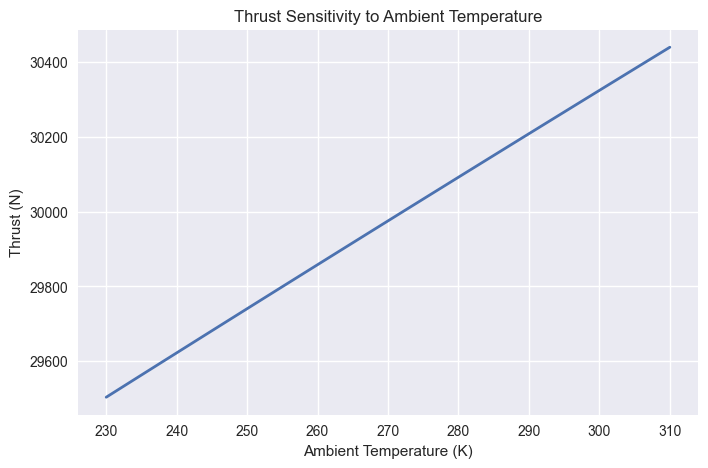

In [30]:
temps = np.linspace(230, 310, 20)   # K
thrusts = []

for T in temps:
    out = engine.run(T, P_ambient)
    thrusts.append(out["thrust_N"])

plt.figure(figsize=(8,5))
plt.plot(temps, thrusts, linewidth=2)
plt.xlabel("Ambient Temperature (K)")
plt.ylabel("Thrust (N)")
plt.title("Thrust Sensitivity to Ambient Temperature")
plt.grid(True)
plt.show()


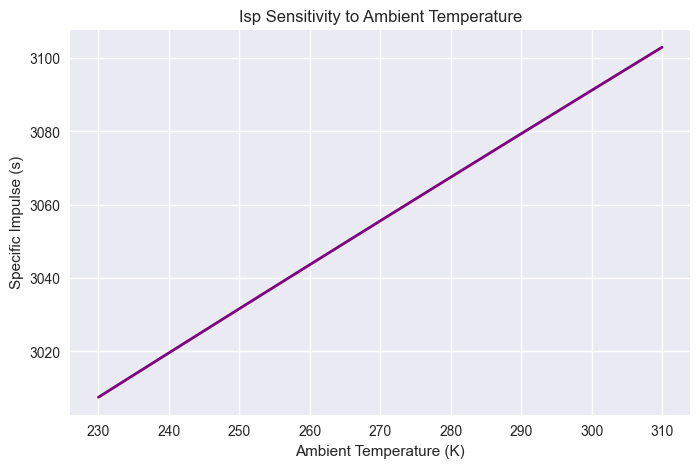

In [31]:
isps = [engine.run(T, P_ambient)["specific_impulse_s"] for T in temps]

plt.figure(figsize=(8,5))
plt.plot(temps, isps, linewidth=2, color="purple")
plt.xlabel("Ambient Temperature (K)")
plt.ylabel("Specific Impulse (s)")
plt.title("Isp Sensitivity to Ambient Temperature")
plt.grid(True)
plt.show()


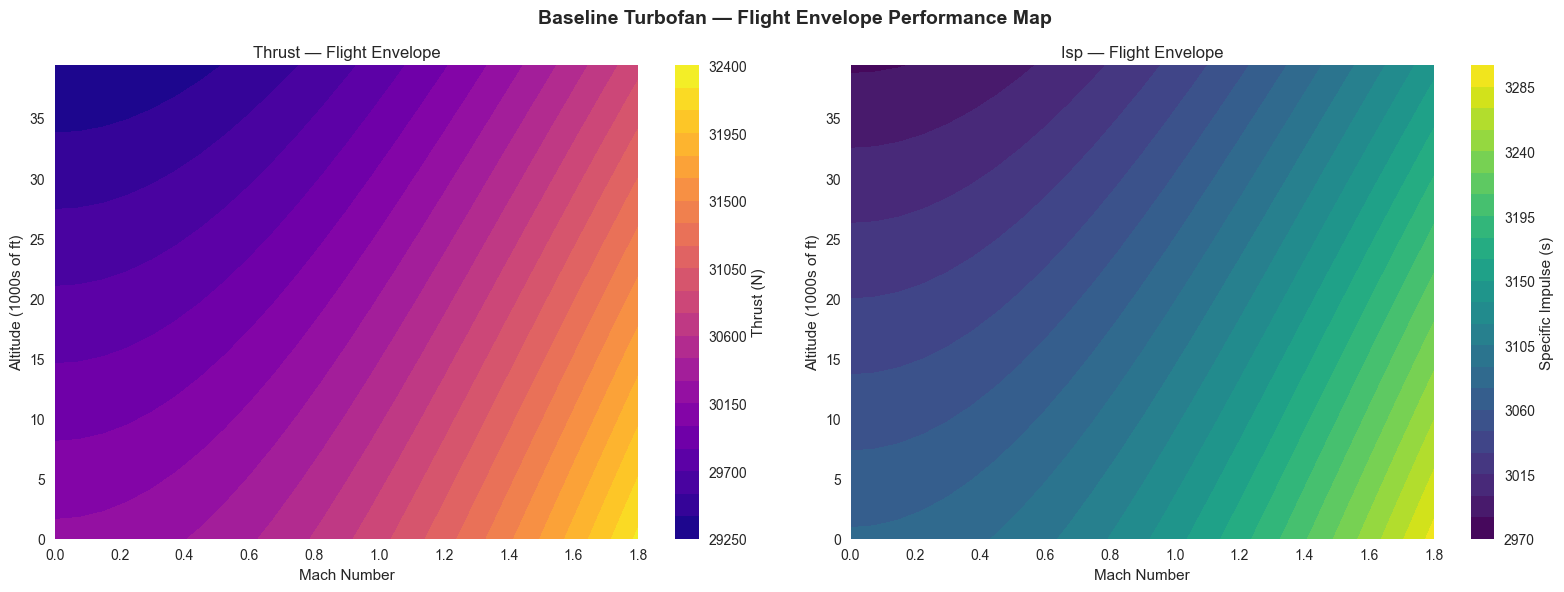

In [32]:
# ============================================================
# FLIGHT ENVELOPE SWEEP — Mach x Altitude Heatmaps
# ============================================================

def isa_atmosphere(altitude_m):
    T = 288.15 - 0.0065 * altitude_m
    P = 101325.0 * (T / 288.15) ** 5.2561
    return T, P

def inlet_total_conditions(T_static, P_static, mach):
    gamma = 1.4
    T0 = T_static * (1.0 + (gamma - 1.0) / 2.0 * mach ** 2)
    P0 = P_static * (T0 / T_static) ** (gamma / (gamma - 1.0))
    return T0, P0

machs     = np.linspace(0.0, 1.8, 25)
altitudes = np.linspace(0, 12000, 25)

thrust_map = np.zeros((len(altitudes), len(machs)))
isp_map    = np.zeros((len(altitudes), len(machs)))

for i, alt in enumerate(altitudes):
    T_s, P_s = isa_atmosphere(alt)
    for j, mach in enumerate(machs):
        T0, P0 = inlet_total_conditions(T_s, P_s, mach)
        out = engine.run(T0, P0)
        thrust_map[i, j] = out["thrust_N"]
        isp_map[i, j]    = out["specific_impulse_s"]

altitudes_ft = altitudes * 3.28084

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cp1 = axes[0].contourf(machs, altitudes_ft / 1000, thrust_map, levels=20, cmap="plasma")
fig.colorbar(cp1, ax=axes[0], label="Thrust (N)")
axes[0].set_xlabel("Mach Number")
axes[0].set_ylabel("Altitude (1000s of ft)")
axes[0].set_title("Thrust — Flight Envelope")
axes[0].grid(True, linestyle="--", alpha=0.4)

cp2 = axes[1].contourf(machs, altitudes_ft / 1000, isp_map, levels=20, cmap="viridis")
fig.colorbar(cp2, ax=axes[1], label="Specific Impulse (s)")
axes[1].set_xlabel("Mach Number")
axes[1].set_ylabel("Altitude (1000s of ft)")
axes[1].set_title("Isp — Flight Envelope")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Baseline Turbofan — Flight Envelope Performance Map", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

The flight envelope maps show that thrust peaks at low altitude / high Mach 
due to ram compression increasing inlet total pressure and temperature. 
Isp follows a similar trend. The nozzle operates in choked flow (M=1) 
across the entire envelope given the high turbine exit pressure ratios.

**Phase 2 baseline validation complete.**